In [144]:
import pandas as pd
df_Credito = pd.read_csv('Datoscredito_alemania.csv')
print('Archivo Datoscredito_alemania.csv cargado correctamente en el DataFrame df_Credito.')
print(df_Credito.head())

Archivo Datoscredito_alemania.csv cargado correctamente en el DataFrame df_Credito.
   Unnamed: 0   Age     Sex  Job Housing Saving accounts Checking account  \
0         0.0  67.0    male  2.0     own             NaN           little   
1         1.0  22.0  female  2.0     own          little         moderate   
2         2.0  49.0    male  1.0     own          little              NaN   
3         3.0  45.0    male  2.0    free          little           little   
4         4.0  53.0    male  2.0    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0         1169.0       6.0             radio/TV  good  
1         5951.0      48.0             radio/TV   bad  
2         2096.0      12.0            education  good  
3         7882.0      42.0  furniture/equipment  good  
4         4870.0      24.0                  car   bad  


In [145]:
df_Credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1061 non-null   float64
 1   Age               1058 non-null   float64
 2   Sex               1052 non-null   object 
 3   Job               1055 non-null   float64
 4   Housing           1052 non-null   object 
 5   Saving accounts   862 non-null    object 
 6   Checking account  635 non-null    object 
 7   Credit amount     1055 non-null   float64
 8   Duration          1056 non-null   float64
 9   Purpose           1051 non-null   object 
 10  Risk              1046 non-null   object 
dtypes: float64(5), object(6)
memory usage: 91.4+ KB


ELIMINACION DE VARIABLE

In [146]:
columns_to_drop = [
    'Unnamed: 0'
]
df_Credito = df_Credito.drop(columns=columns_to_drop)

print("Columnas eliminadas. Primeras columna del DataFrame actualizado:")
display(df_Credito.head())
print("Información del DataFrame actualizado:")
df_Credito.info()

Columnas eliminadas. Primeras columna del DataFrame actualizado:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67.0,male,2.0,own,NaN,little,1169.0,6.0,radio/TV,good
1,22.0,female,2.0,own,little,moderate,5951.0,48.0,radio/TV,bad
2,49.0,male,1.0,own,little,NaN,2096.0,12.0,education,good
3,45.0,male,2.0,free,little,little,7882.0,42.0,furniture/equipment,good
4,53.0,male,2.0,free,little,little,4870.0,24.0,car,bad


Información del DataFrame actualizado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1058 non-null   float64
 1   Sex               1052 non-null   object 
 2   Job               1055 non-null   float64
 3   Housing           1052 non-null   object 
 4   Saving accounts   862 non-null    object 
 5   Checking account  635 non-null    object 
 6   Credit amount     1055 non-null   float64
 7   Duration          1056 non-null   float64
 8   Purpose           1051 non-null   object 
 9   Risk              1046 non-null   object 
dtypes: float64(4), object(6)
memory usage: 83.1+ KB


CAMBIAR TIPO DE DATOS

In [147]:
for col in df_Credito.select_dtypes(include='object').columns:
    df_Credito[col] = df_Credito[col].astype('category')

print("Data types after conversion:")
df_Credito.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1058 non-null   float64 
 1   Sex               1052 non-null   category
 2   Job               1055 non-null   float64 
 3   Housing           1052 non-null   category
 4   Saving accounts   862 non-null    category
 5   Checking account  635 non-null    category
 6   Credit amount     1055 non-null   float64 
 7   Duration          1056 non-null   float64 
 8   Purpose           1051 non-null   category
 9   Risk              1046 non-null   category
dtypes: category(6), float64(4)
memory usage: 40.6 KB


ANALISIS DESCRIPTIVO

In [148]:
df_Credito.describe()

,Age,Job,Credit amount,Duration
count,1058.000000,1055.000000,1055.000000,1056.000000
mean,35.483932,1.906161,3269.879621,20.942235
std,11.285586,0.648828,2800.110643,12.091573
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1364.000000,12.000000
50%,33.000000,2.000000,2320.000000,18.000000
75%,42.000000,2.000000,3984.500000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


DIAGRAMA DE CAJAS

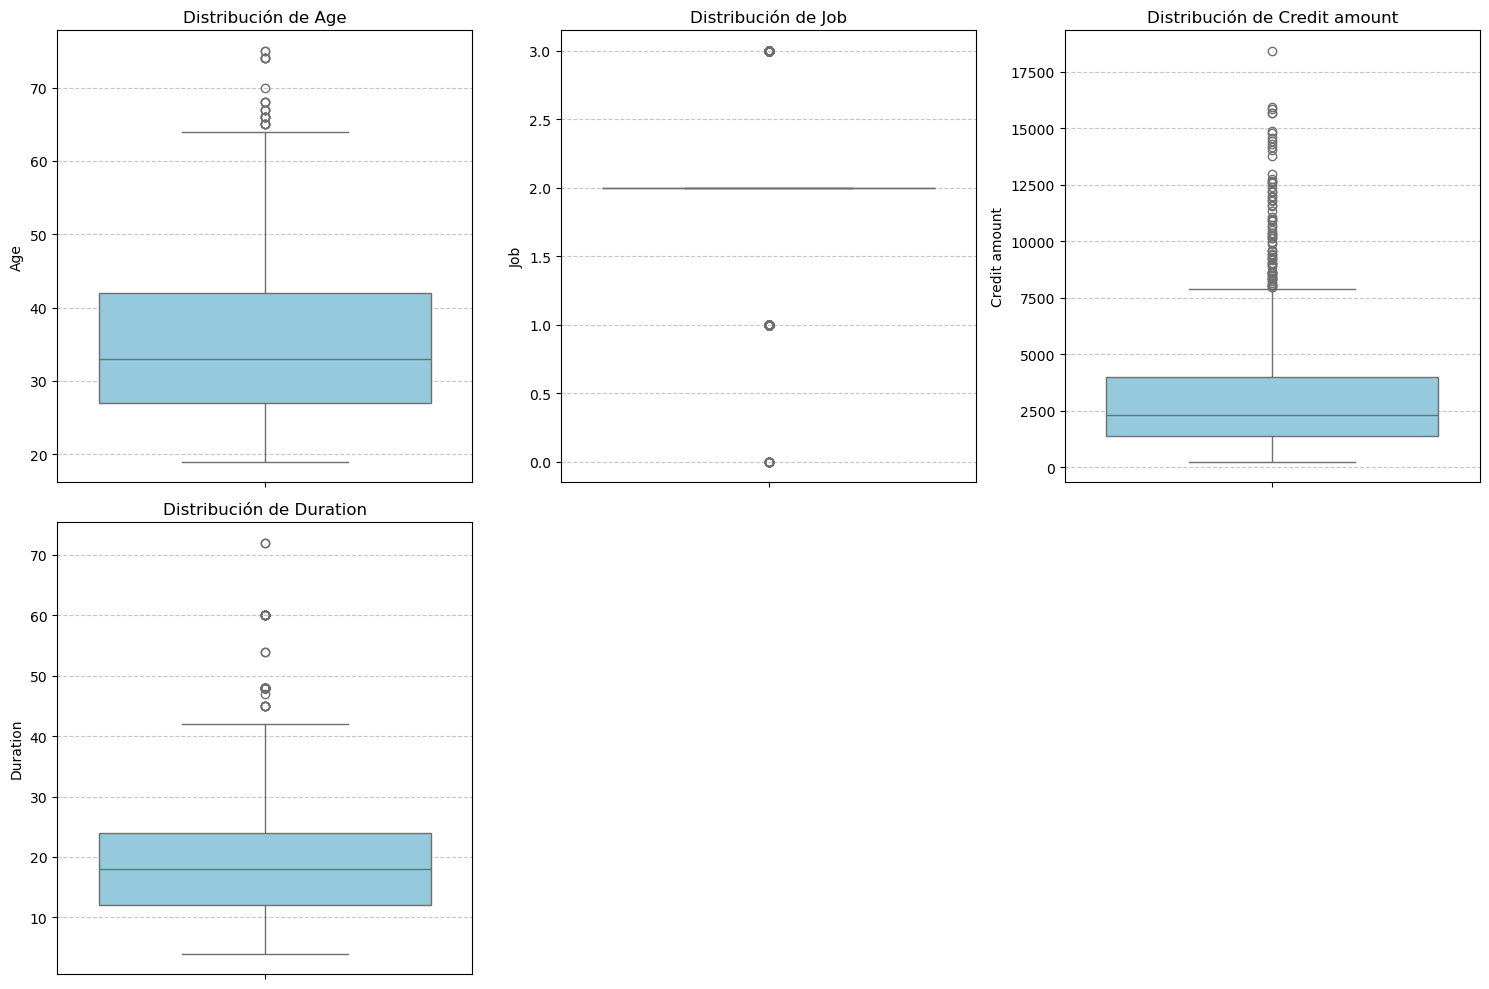

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos solo las columnas numéricas para evitar errores con texto
cols_numericas = df_Credito.select_dtypes(include=['number']).columns

# 2. Configuramos el tamaño de la figura según la cantidad de variables
# Ajustamos el layout para que no se amontonen
plt.figure(figsize=(15, 10))

# 3. Creamos un bucle para generar un subplot por cada variable
for i, col in enumerate(cols_numericas):
    plt.subplot(len(cols_numericas) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df_Credito[col], color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Ajustar el espacio entre gráficas y mostrar
plt.tight_layout()
plt.show()

IMPUTACION DE VALORES ATIPICOS

In [150]:
import numpy as np

print("Imputando valores atípicos con la media aritmética...")

# Identify numerical columns (excluding the target 'CUPO_APROBADO' from being considered for imputation if it contains outliers that are not errors)
numerical_cols_for_imputation = df_Credito.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols_for_imputation:
    Q1 = df_Credito[col].quantile(0.25)
    Q3 = df_Credito[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers_mask = (df_Credito[col] < lower_bound) | (df_Credito[col] > upper_bound)
    num_outliers = outliers_mask.sum()

    if num_outliers > 0:
        column_mean = df_Credito[col].mean()
        df_Credito.loc[outliers_mask, col] = column_mean
        print(f"Se imputaron {num_outliers} valores atípicos en la columna '{col}' con la media ({column_mean:.2f}).")
    else:
        print(f"No se encontraron valores atípicos en la columna '{col}'.")

print("\nPrimeras 5 filas del DataFrame después de la imputación:")
display(df_Credito.head())

Imputando valores atípicos con la media aritmética...
Se imputaron 23 valores atípicos en la columna 'Age' con la media (35.48).
Se imputaron 387 valores atípicos en la columna 'Job' con la media (1.91).
Se imputaron 75 valores atípicos en la columna 'Credit amount' con la media (3269.88).
Se imputaron 73 valores atípicos en la columna 'Duration' con la media (20.94).

Primeras 5 filas del DataFrame después de la imputación:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,35.483932,male,2.000000,own,NaN,little,1169.0,6.000000,radio/TV,good
1,22.000000,female,2.000000,own,little,moderate,5951.0,20.942235,radio/TV,bad
2,49.000000,male,1.906161,own,little,NaN,2096.0,12.000000,education,good
3,45.000000,male,2.000000,free,little,little,7882.0,42.000000,furniture/equipment,good
4,53.000000,male,2.000000,free,little,little,4870.0,24.000000,car,bad


VALORES NULOS

In [151]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import joblib

cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']
num_cols = ['Age', 'Job', 'Duration', 'Credit amount']

# 2. Copia y Encoding
df_knn = df_Credito.copy()
encoders = {}

for col in cat_cols:
    if col in df_knn.columns:
        df_knn[col] = df_knn[col].astype(object)
        mask = df_knn[col].notnull()
        le = LabelEncoder()
        # Usamos .loc para evitar SettingWithCopyWarning
        df_knn.loc[mask, col] = le.fit_transform(df_knn.loc[mask, col].astype(str))
        encoders[col] = le

# 3. Imputación KNN
imputer = KNNImputer(n_neighbors=5)
# Es vital que solo usemos las columnas que realmente existen en el DF
cols_to_use = [c for c in (num_cols + cat_cols) if c in df_knn.columns]
imputed_data = imputer.fit_transform(df_knn[cols_to_use])

# Creamos el DF temporal con el MISMO índice que df_Credito
df_filled = pd.DataFrame(imputed_data, columns=cols_to_use, index=df_Credito.index)

# 4. Actualización del DataFrame Original
# Columnas Numéricas
for col in num_cols:
    if col in df_filled.columns:
        df_Credito[col] = df_filled[col]

# Columnas Categóricas
for col in cat_cols:
    if col in df_filled.columns and col in encoders:
        # Redondeamos porque KNN devuelve promedios decimales
        indices = df_filled[col].round().astype(int)
        le = encoders[col]

        # Clip para evitar que un redondeo nos saque del rango de clases
        indices = indices.clip(0, len(le.classes_) - 1)

        # Invertimos el encoding y asignamos usando el índice correcto
        df_Credito[col] = le.inverse_transform(indices)
        df_Credito[col] = df_Credito[col].astype('category')

# 5. Forzar tipos de datos (con manejo de errores si no existen)
cols_to_int = ['Age', 'Job', 'Duration']
for col in cols_to_int:
    if col in df_Credito.columns:
        df_Credito[col] = df_Credito[col].astype(int)

if 'Credit amount' in df_Credito.columns:
    df_Credito['Credit amount'] = df_Credito['Credit amount'].astype(float)

# Verificación final
print('Final Null Count Summary:')
print(df_Credito.isnull().sum())
df_Credito.info()

# Save the DataFrame using joblib
joblib.dump(df_Credito, 'df_Credito1.joblib')
print("DataFrame 'df_Credito' saved as 'df_Credito1.joblib'")

Final Null Count Summary:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1062 non-null   int32   
 1   Sex               1062 non-null   category
 2   Job               1062 non-null   int32   
 3   Housing           1062 non-null   category
 4   Saving accounts   1062 non-null   category
 5   Checking account  1062 non-null   category
 6   Credit amount     1062 non-null   float64 
 7   Duration          1062 non-null   int32   
 8   Purpose           1062 non-null   category
 9   Risk              1062 non-null   category
dtypes: category(6), float64(1), int32(3)
memory usage: 28

ANALISIS GENERAL 

In [152]:
from ydata_profiling import ProfileReport

# Generar el reporte de profiling
profile = ProfileReport(df_Credito, title="Reporte de Profiling - Clientes Banca")

# Guardar el reporte en HTML
profile.to_file("reporte_profiling.html")

print("Reporte generado exitosamente: reporte_profiling.html")

import webbrowser
import os

# Esto abrirá el archivo en tu navegador predeterminado
webbrowser.open('file://' + os.path.realpath("reporte_profiling.html"))

Summarize dataset:  71%|███████   | 12/17 [00:00<00:00, 19.96it/s, Calculate auto correlation]c:\Users\Personal\anaconda3\envs\ModuloMachineLearning\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3 0 6 ... 0 2 6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
c:\Users\Personal\anaconda3\envs\ModuloMachineLearning\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9 9 0 ... 9 9 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
c:\Users\Personal\anaconda3\envs\ModuloMachineLearning\lib\site-packages\ydata_profili

Reporte generado exitosamente: reporte_profiling.html


True

DATOS DUPLICADO ELIMINACION

In [153]:
initial_rows = df_Credito.shape[0]
df_Credito.drop_duplicates(inplace=True)
final_rows = df_Credito.shape[0]

print(f"Filas iniciales: {initial_rows}")
print(f"Filas después de eliminar duplicados: {final_rows}")
print(f"Se eliminaron {initial_rows - final_rows} filas duplicadas.")

print("Primeras filas del DataFrame después de eliminar duplicados:")
print(df_Credito.head())
print("Información del DataFrame actualizado:")

Filas iniciales: 1062
Filas después de eliminar duplicados: 1021
Se eliminaron 41 filas duplicadas.
Primeras filas del DataFrame después de eliminar duplicados:
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   35    male    2     own        moderate           little         1169.0   
1   22  female    2     own          little         moderate         5951.0   
2   49    male    1     own          little         moderate         2096.0   
3   45    male    2    free          little           little         7882.0   
4   53    male    2    free          little           little         4870.0   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        20             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  
Información del DataFrame actualizado:


In [154]:
df_Credito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1058
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1021 non-null   int32   
 1   Sex               1021 non-null   category
 2   Job               1021 non-null   int32   
 3   Housing           1021 non-null   category
 4   Saving accounts   1021 non-null   category
 5   Checking account  1021 non-null   category
 6   Credit amount     1021 non-null   float64 
 7   Duration          1021 non-null   int32   
 8   Purpose           1021 non-null   category
 9   Risk              1021 non-null   category
dtypes: category(6), float64(1), int32(3)
memory usage: 35.0 KB


CORRELACIONES 

--- Matriz de Correlación de Spearman (Relaciones Monótonas) ---


,Age,Job,Credit amount,Duration
Age,1.000000,-0.130814,0.038435,-0.024503
Job,-0.130814,1.000000,-0.002629,0.067814
Credit amount,0.038435,-0.002629,1.000000,0.530846
Duration,-0.024503,0.067814,0.530846,1.000000


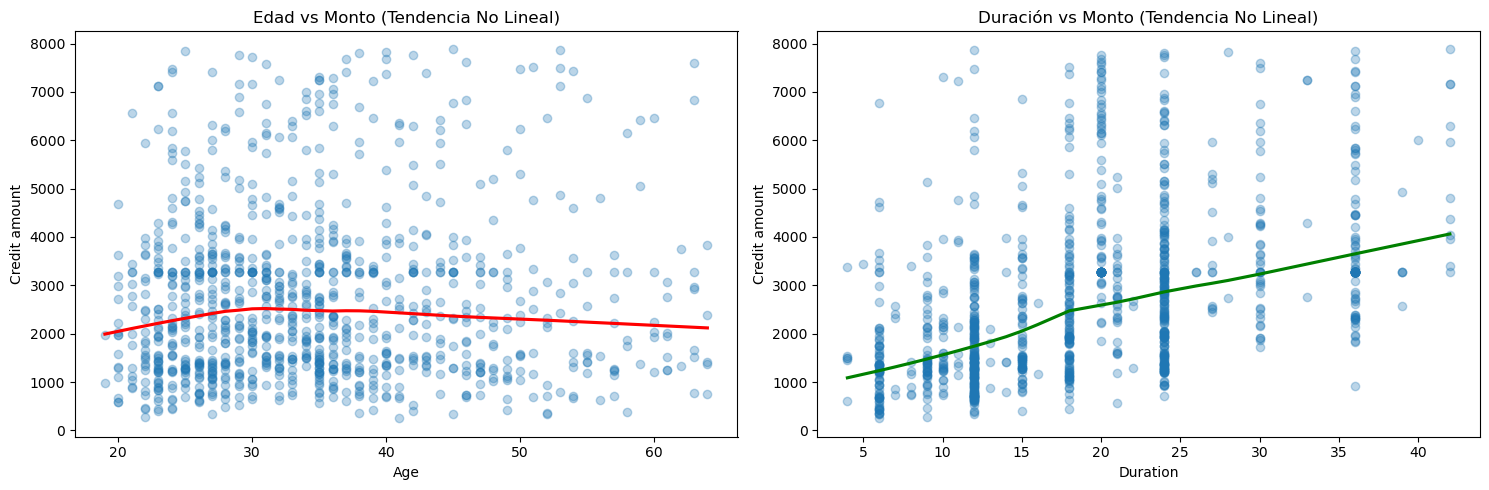

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Correlación de Spearman (Detecta relaciones monótonas no lineales)
num_cols = ['Age', 'Job', 'Credit amount', 'Duration']
corr_spearman = df_Credito[num_cols].corr(method='spearman')

print("--- Matriz de Correlación de Spearman (Relaciones Monótonas) ---")
display(corr_spearman)

# 2. Visualización de tendencias no lineales con LOWESS
plt.figure(figsize=(15, 5))

# Edad vs Monto
plt.subplot(1, 2, 1)
sns.regplot(x='Age', y='Credit amount', data=df_Credito, lowess=True,
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
plt.title('Edad vs Monto (Tendencia No Lineal)')

# Duración vs Monto
plt.subplot(1, 2, 2)
sns.regplot(x='Duration', y='Credit amount', data=df_Credito, lowess=True,
            line_kws={'color': 'green'}, scatter_kws={'alpha': 0.3})
plt.title('Duración vs Monto (Tendencia No Lineal)')

plt.tight_layout()
plt.show()

--- Correlación de Pearson para variables numéricas ---
El mapa de calor de correlación de Pearson para las variables numéricas (Age, Job, Duration, Credit amount) se mostró previamente.
Aquí está la matriz de correlación numérica para referencia:


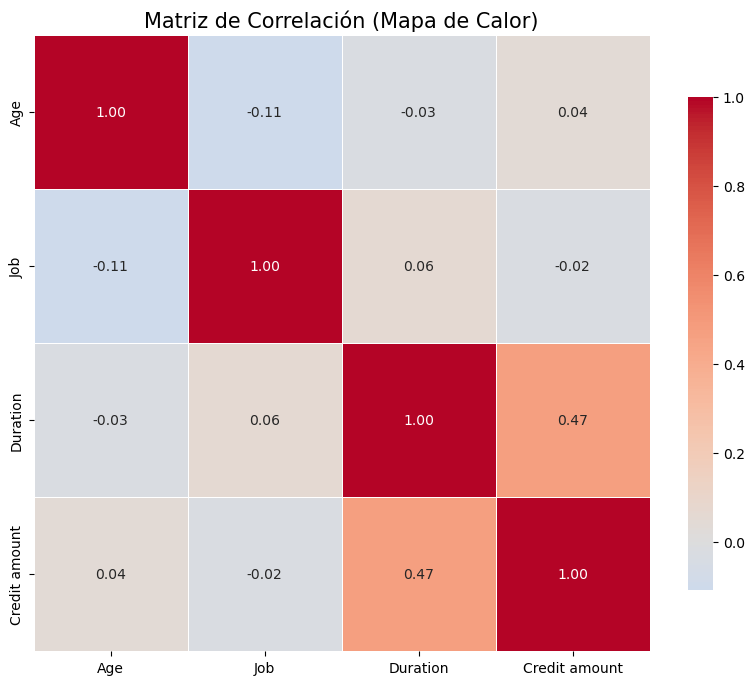

,Age,Job,Duration,Credit amount
Age,1.000000,-0.107259,-0.025857,0.042130
Job,-0.107259,1.000000,0.061916,-0.023530
Duration,-0.025857,0.061916,1.000000,0.469528
Credit amount,0.042130,-0.023530,0.469528,1.000000




--- Análisis de Asociación para variables categóricas con 'Risk' ---

Resultados de las pruebas de asociación (ordenados por Cramer's V de mayor a menor):



,Variable,Chi-Cuadrado,Valor p,Cramer's V
3,Checking account,50.815532,9.237352e-12,0.223093
1,Housing,16.996200,2.038554e-04,0.129022
2,Saving accounts,14.846185,1.952926e-03,0.120585
4,Purpose,13.670818,5.735566e-02,0.115714
0,Sex,4.566566,3.260186e-02,0.066878


In [156]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Display Pearson Correlation results (already computed and shown as heatmap)
print("--- Correlación de Pearson para variables numéricas ---")
print("El mapa de calor de correlación de Pearson para las variables numéricas (Age, Job, Duration, Credit amount) se mostró previamente.")
print("Aquí está la matriz de correlación numérica para referencia:")
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix for numerical features
corr_matrix = df_Credito[['Age', 'Job', 'Duration', 'Credit amount']].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={'shrink': .8})

plt.title('Matriz de Correlación (Mapa de Calor)', fontsize=15)
plt.show()
display(corr_matrix) # corr_matrix is available in kernel state

print("\n" + "="*80 + "\n")

# Association analysis for categorical variables (Chi-square, p-value, Cramer's V)
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
objective_variable = 'Risk'

cramers_v_results = []

print(f"--- Análisis de Asociación para variables categóricas con '{objective_variable}' ---")

for col in categorical_cols:
    if col in df_Credito.columns and objective_variable in df_Credito.columns:
        contingency_table = pd.crosstab(df_Credito[col], df_Credito[objective_variable])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        n = contingency_table.sum().sum()
        k = contingency_table.shape[0] # Number of rows (categories of 'col')
        r = contingency_table.shape[1] # Number of columns (categories of 'Risk')

        # Calculate Cramer's V
        min_dim = np.min([k - 1, r - 1])
        if n > 0 and min_dim > 0:
            cramers_v = np.sqrt((chi2 / n) / min_dim)
        else:
            cramers_v = np.nan # Cannot calculate if n is 0 or min_dim is 0

        cramers_v_results.append({
            'Variable': col,
            'Chi-Cuadrado': chi2,
            'Valor p': p_value,
            'Cramer\'s V': cramers_v
        })
    else:
        print(f"Advertencia: La columna '{col}' o '{objective_variable}' no se encuentra en el DataFrame.")

# Convert results to a DataFrame for easier sorting and display
cramers_v_df = pd.DataFrame(cramers_v_results)

# Sort by Cramer's V statistic in descending order
if not cramers_v_df.empty:
    cramers_v_df_sorted = cramers_v_df.sort_values(by="Cramer's V", ascending=False)
    print("\nResultados de las pruebas de asociación (ordenados por Cramer's V de mayor a menor):\n")
    display(cramers_v_df_sorted)
else:
    print("\nNo se pudieron calcular los resultados de asociación para las variables categóricas.")

ELIMINACION DE VARIABLE

In [157]:
# Definir las columnas a eliminar
columns_to_drop = ['Sex']

# Eliminar solo las columnas que existan en el DataFrame
existing_cols = [col for col in columns_to_drop if col in df_Credito.columns]
df_Credito = df_Credito.drop(columns=existing_cols)

print(f"Columnas eliminadas: {existing_cols}")
print("\nInformación del DataFrame actualizado:")
df_Credito.info()
display(df_Credito.head())

Columnas eliminadas: ['Sex']

Información del DataFrame actualizado:
<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1058
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1021 non-null   int32   
 1   Job               1021 non-null   int32   
 2   Housing           1021 non-null   category
 3   Saving accounts   1021 non-null   category
 4   Checking account  1021 non-null   category
 5   Credit amount     1021 non-null   float64 
 6   Duration          1021 non-null   int32   
 7   Purpose           1021 non-null   category
 8   Risk              1021 non-null   category
dtypes: category(5), float64(1), int32(3)
memory usage: 33.8 KB


,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,35,2,own,moderate,little,1169.0,6,radio/TV,good
1,22,2,own,little,moderate,5951.0,20,radio/TV,bad
2,49,1,own,little,moderate,2096.0,12,education,good
3,45,2,free,little,little,7882.0,42,furniture/equipment,good
4,53,2,free,little,little,4870.0,24,car,bad


LABELENCODER-ONEHOTENCODER

In [158]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd
import joblib

# 1. Definir columnas por tipo de tratamiento
ordinal_col = 'Risk'
# Agregamos 'Purpose' a las nominales para OneHotEncoding
nominal_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

# --- APLICAR LABEL ENCODER (Para la variable objetivo 'Risk') ---
if ordinal_col in df_Credito.columns:
    le = LabelEncoder()
    df_Credito[f'{ordinal_col}_ENCODED'] = le.fit_transform(df_Credito[ordinal_col])
    print(f"LabelEncoder aplicado a '{ordinal_col}'. Clases: {list(le.classes_)}")
    df_Credito = df_Credito.drop(columns=[ordinal_col])
else:
    print(f"Columna '{ordinal_col}' no encontrada.")

# --- APLICAR ONE-HOT ENCODER (Para todas las nominales, incluyendo Purpose) ---
# Validamos qué columnas de la lista realmente existen en el DataFrame
cols_to_onehot = [col for col in nominal_cols if col in df_Credito.columns]

if cols_to_onehot:
    # sparse_output=False para obtener un array denso compatible con DataFrame
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Ajustar y transformar las columnas seleccionadas
    ohe_data = ohe.fit_transform(df_Credito[cols_to_onehot])

    # Obtener nombres de las nuevas columnas (ej. Purpose_car, Purpose_education)
    ohe_feature_names = ohe.get_feature_names_out(cols_to_onehot)

    # Crear DataFrame con las nuevas columnas transformadas
    df_ohe = pd.DataFrame(ohe_data, columns=ohe_feature_names, index=df_Credito.index)

    # Concatenar con el DataFrame original y eliminar las columnas categóricas viejas
    df_Credito = pd.concat([df_Credito, df_ohe], axis=1)
    df_Credito = df_Credito.drop(columns=cols_to_onehot)
    
    print(f"OneHotEncoder aplicado con éxito a: {cols_to_onehot}")
else:
    print("No se encontraron columnas nominales para procesar.")

# --- RESULTADOS Y GUARDADO ---
print("\nDataset procesado:")
print(df_Credito.head())
df_Credito.info()

# Nota: Es mejor guardar el OBJETO del transformador (ohe) si vas a predecir datos nuevos después,
# pero aquí guardamos el DataFrame procesado como pediste:
joblib.dump(df_Credito, 'df_Credito_encoded.joblib')
print("\nDataFrame 'df_Credito' guardado como 'df_Credito_encoded.joblib'")
joblib.dump(ohe, 'ohe_model.joblib')
joblib.dump(le, 'le_model.joblib')

LabelEncoder aplicado a 'Risk'. Clases: ['bad', 'good']
OneHotEncoder aplicado con éxito a: ['Housing', 'Saving accounts', 'Checking account', 'Purpose']

Dataset procesado:
   Age  Job  Credit amount  Duration  Risk_ENCODED  Housing_free  Housing_own  \
0   35    2         1169.0         6             1           0.0          1.0   
1   22    2         5951.0        20             0           0.0          1.0   
2   49    1         2096.0        12             1           0.0          1.0   
3   45    2         7882.0        42             1           1.0          0.0   
4   53    2         4870.0        24             0           1.0          0.0   

   Housing_rent  Saving accounts_little  Saving accounts_moderate  ...  \
0           0.0                     0.0                       1.0  ...   
1           0.0                     1.0                       0.0  ...   
2           0.0                     1.0                       0.0  ...   
3           0.0                     1.0    

['le_model.joblib']

In [159]:
df_Credito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1058
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1021 non-null   int32  
 1   Job                          1021 non-null   int32  
 2   Credit amount                1021 non-null   float64
 3   Duration                     1021 non-null   int32  
 4   Risk_ENCODED                 1021 non-null   int32  
 5   Housing_free                 1021 non-null   float64
 6   Housing_own                  1021 non-null   float64
 7   Housing_rent                 1021 non-null   float64
 8   Saving accounts_little       1021 non-null   float64
 9   Saving accounts_moderate     1021 non-null   float64
 10  Saving accounts_quite rich   1021 non-null   float64
 11  Saving accounts_rich         1021 non-null   float64
 12  Checking account_little      1021 non-null   float64
 13  Checking account_modera

ESCALADOR

In [160]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Identificar columnas numéricas que necesitan escalado
# Nota: No escalamos las columnas que acabamos de crear con OneHotEncoding (que son 0 y 1)
numeric_cols = ['Age', 'Credit amount', 'Duration', 'Job']

# --- APLICAR STANDARD SCALER ---
# Verificamos cuáles de estas columnas están presentes en el DataFrame
cols_to_scale = [col for col in numeric_cols if col in df_Credito.columns]

if cols_to_scale:
    scaler = StandardScaler()
    
    # Ajustar y transformar solo las columnas numéricas
    df_Credito[cols_to_scale] = scaler.fit_transform(df_Credito[cols_to_scale])
    
    print(f"StandardScaler aplicado a: {cols_to_scale}")
    
    # Es VITAL guardar el objeto scaler para usarlo después con datos nuevos
    joblib.dump(scaler, 'scaler_model.joblib')
else:
    print("No se encontraron columnas numéricas para escalar.")

# --- VERIFICAR RESULTADO FINAL ---
print("\nPrimeras filas con datos escalados:")
print(df_Credito[cols_to_scale].head())

# Guardar el dataset final completamente procesado
joblib.dump(df_Credito, 'df_Credito_final.joblib')
print("\nDataset final guardado como 'df_Credito_final.joblib'")

StandardScaler aplicado a: ['Age', 'Credit amount', 'Duration', 'Job']

Primeras filas con datos escalados:
        Age  Credit amount  Duration       Job
0  0.029607      -0.893045 -1.457721  0.766726
1 -1.254615       1.871811  0.142391  0.766726
2  1.412615      -0.357072 -0.771959 -1.304246
3  1.017470       2.988276  2.656854  0.766726
4  1.807760       1.246798  0.599567  0.766726

Dataset final guardado como 'df_Credito_final.joblib'


In [161]:
df_Credito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1058
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1021 non-null   float64
 1   Job                          1021 non-null   float64
 2   Credit amount                1021 non-null   float64
 3   Duration                     1021 non-null   float64
 4   Risk_ENCODED                 1021 non-null   int32  
 5   Housing_free                 1021 non-null   float64
 6   Housing_own                  1021 non-null   float64
 7   Housing_rent                 1021 non-null   float64
 8   Saving accounts_little       1021 non-null   float64
 9   Saving accounts_moderate     1021 non-null   float64
 10  Saving accounts_quite rich   1021 non-null   float64
 11  Saving accounts_rich         1021 non-null   float64
 12  Checking account_little      1021 non-null   float64
 13  Checking account_modera

PCA

In [162]:
from sklearn.decomposition import PCA
import pandas as pd
import joblib

# 1. Preparar los datos (X)
# Eliminamos la variable objetivo para el PCA
if 'Risk_ENCODED' in df_Credito.columns:
    X = df_Credito.drop(columns=['Risk_ENCODED'])
else:
    X = df_Credito

# 2. Configurar y aplicar PCA
# Elegimos n_components=0.95 para mantener el 95% de la varianza explicada
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

# 3. Crear el nuevo DataFrame con los componentes principales
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(data=X_pca, columns=pca_cols, index=df_Credito.index)

# Si deseas conservar la variable objetivo para el entrenamiento posterior:
if 'Risk_ENCODED' in df_Credito.columns:
    df_pca['Risk_ENCODED'] = df_Credito['Risk_ENCODED']

# 4. Mostrar información del resultado
print(f"Número de características originales: {X.shape[1]}")
print(f"Número de componentes tras PCA (95% varianza): {len(pca_cols)}")
print("\nVarianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# --- MOSTRAR EL DATASET ---
print("\n--- DATASET FINAL CON PCA ---")
print(df_pca.head())

# Guardar el modelo PCA y el dataset resultante
joblib.dump(pca, 'pca_model.joblib')
joblib.dump(df_pca, 'df_Credito_pca.joblib')

Número de características originales: 22
Número de componentes tras PCA (95% varianza): 12

Varianza explicada por cada componente:
[0.23964236 0.18356597 0.14555992 0.08689086 0.07550698 0.05588453
 0.04330829 0.04053045 0.03327108 0.01883182 0.0183265  0.01563057]

--- DATASET FINAL CON PCA ---
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.705431 -0.533127  0.709539 -0.230227 -0.271257 -0.096975  0.062771   
1  1.378119 -1.290065 -0.402754 -1.227798  0.481530  1.002328 -0.099461   
2 -0.813235  1.943283  0.069177 -0.035619  0.392862  0.490901 -0.114734   
3  4.096262  0.247583  1.078329 -0.111361 -1.238081  0.121813 -0.560656   
4  1.455545  0.957742  1.744133 -0.416906 -1.269828 -0.393893  0.088265   

        PC8       PC9      PC10      PC11      PC12  Risk_ENCODED  
0 -1.434438 -0.539852  0.034489  0.048145 -0.325902             1  
1 -0.183197 -0.569964 -0.022672 -0.126336 -0.067745             0  
2  0.251416  0.349728  0.250953  0.250052 -0.06

['df_Credito_pca.joblib']

BALANCEO

In [163]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import joblib

# 1. Separar las características (X) de la variable objetivo (y)
# Usamos el DataFrame df_pca que creamos en el paso anterior
X_pca = df_pca.drop(columns=['Risk_ENCODED'])
y = df_pca['Risk_ENCODED']

# 2. Configurar y aplicar SMOTE
# random_state asegura que los resultados sean reproducibles
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_pca, y)

# 3. Crear el nuevo DataFrame balanceado
df_balanceado = pd.DataFrame(X_resampled, columns=X_pca.columns)
df_balanceado['Risk_ENCODED'] = y_resampled

# --- VERIFICACIÓN DE RESULTADOS ---
print("Distribución ANTES del balanceo:")
print(y.value_counts())

print("\nDistribución DESPUÉS del balanceo:")
print(y_resampled.value_counts())

print("\n--- DATASET FINAL BALANCEADO (Primeras filas) ---")
print(df_balanceado.head())

# Guardar el dataset balanceado para el entrenamiento del modelo
joblib.dump(df_balanceado, 'df_Credito_balanceado.joblib')
print("\nDataset balanceado guardado como 'df_Credito_balanceado.joblib'")

Distribución ANTES del balanceo:
Risk_ENCODED
1    713
0    308
Name: count, dtype: int64

Distribución DESPUÉS del balanceo:
Risk_ENCODED
1    713
0    713
Name: count, dtype: int64

--- DATASET FINAL BALANCEADO (Primeras filas) ---
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.705431 -0.533127  0.709539 -0.230227 -0.271257 -0.096975  0.062771   
1  1.378119 -1.290065 -0.402754 -1.227798  0.481530  1.002328 -0.099461   
2 -0.813235  1.943283  0.069177 -0.035619  0.392862  0.490901 -0.114734   
3  4.096262  0.247583  1.078329 -0.111361 -1.238081  0.121813 -0.560656   
4  1.455545  0.957742  1.744133 -0.416906 -1.269828 -0.393893  0.088265   

        PC8       PC9      PC10      PC11      PC12  Risk_ENCODED  
0 -1.434438 -0.539852  0.034489  0.048145 -0.325902             1  
1 -0.183197 -0.569964 -0.022672 -0.126336 -0.067745             0  
2  0.251416  0.349728  0.250953  0.250052 -0.066266             1  
3 -0.254355  0.454983  0.399450 -0.662366 -

MODELOS DE REGRESION LOGISTICA

       MODELO DE REGRESIÓN LOGÍSTICA

Accuracy (70/30):        0.6706

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.68      0.65      0.66       214
           1       0.66      0.69      0.68       214

    accuracy                           0.67       428
   macro avg       0.67      0.67      0.67       428
weighted avg       0.67      0.67      0.67       428

Precisión Promedio (CV): 0.6459
Desviación Estándar(CV): 0.0272
Scores por fold:         [0.6538 0.6456 0.6281 0.6912 0.6105]


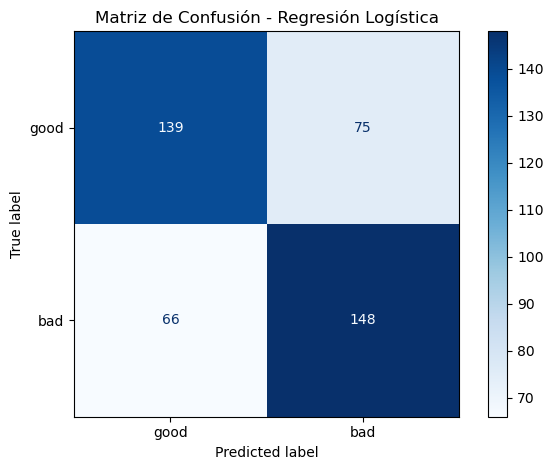

In [164]:
# ============================================================
# MODELO DE REGRESIÓN LOGÍSTICA
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt
import joblib

# --- Cargar datos balanceados ---
df_balanceado = joblib.load('df_Credito_balanceado.joblib')

X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

# --- División 70/30 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# --- Entrenamiento ---
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# --- Predicción ---
y_pred = modelo_lr.predict(X_test)

# --- Métricas ---
print("=" * 55)
print("       MODELO DE REGRESIÓN LOGÍSTICA")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# --- Validación cruzada (precisión, promedio y desviación) ---
cv_scores = cross_val_score(modelo_lr, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.tight_layout()
plt.show()



HIPERAJUSTE DEL MODELO DE REGRESION LOGISTICA

Fitting 5 folds for each of 10 candidates, totalling 50 fits
   REGRESIÓN LOGÍSTICA - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor F1 (CV/train): 0.6347

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.68      0.65      0.66       214
 Clase 1 (bad)       0.66      0.69      0.68       214

      accuracy                           0.67       428
     macro avg       0.67      0.67      0.67       428
  weighted avg       0.67      0.67      0.67       428



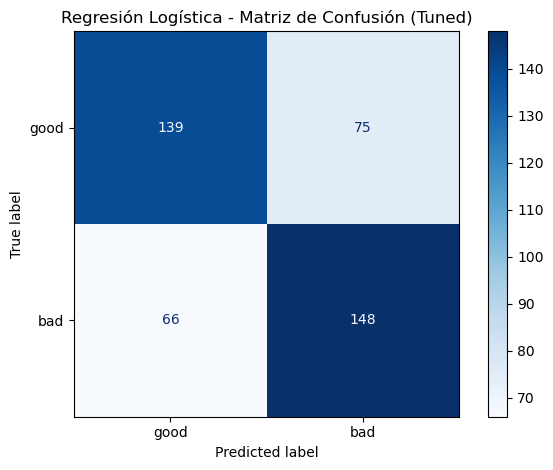

In [165]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - REGRESIÓN LOGÍSTICA
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

# División 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# GridSearchCV SOLO sobre el 70% (X_train)
param_grid = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'solver':   ['lbfgs', 'liblinear'],
    'penalty':  ['l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)   # <-- Solo X_train (70%)

print("=" * 55)
print("   REGRESIÓN LOGÍSTICA - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {grid_lr.best_params_}")
print(f"Mejor F1 (CV/train): {grid_lr.best_score_:.4f}")

# Evaluación final sobre el 30% NO visto
y_pred = grid_lr.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='Blues')
plt.title("Regresión Logística - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()




MODELO DE ARBOL DE DECISIONES

       MODELO DE ÁRBOL DE DECISIONES

Accuracy (70/30):        0.6495

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.66      0.62      0.64       214
           1       0.64      0.68      0.66       214

    accuracy                           0.65       428
   macro avg       0.65      0.65      0.65       428
weighted avg       0.65      0.65      0.65       428

Precisión Promedio (CV): 0.6613
Desviación Estándar(CV): 0.0230
Scores por fold:         [0.6713 0.6772 0.6807 0.6596 0.6175]


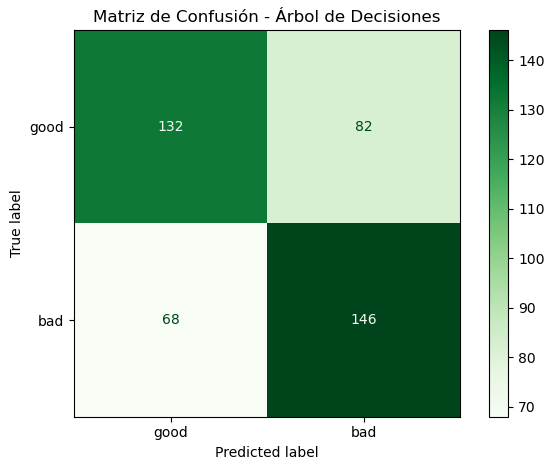

In [166]:
# ============================================================
# MODELO DE ÁRBOL DE DECISIONES
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred = modelo_dt.predict(X_test)

print("=" * 55)
print("       MODELO DE ÁRBOL DE DECISIONES")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_dt, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='Greens')
plt.title("Matriz de Confusión - Árbol de Decisiones")
plt.tight_layout()
plt.show()



AJUSTE DE HIPERPARÁMETROS - ÁRBOL DE DECISIONES

Fitting 5 folds for each of 90 candidates, totalling 450 fits
   ÁRBOL DE DECISIONES - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor F1 (CV/train): 0.6749

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.67      0.78      0.72       214
 Clase 1 (bad)       0.73      0.62      0.67       214

      accuracy                           0.70       428
     macro avg       0.70      0.70      0.70       428
  weighted avg       0.70      0.70      0.70       428



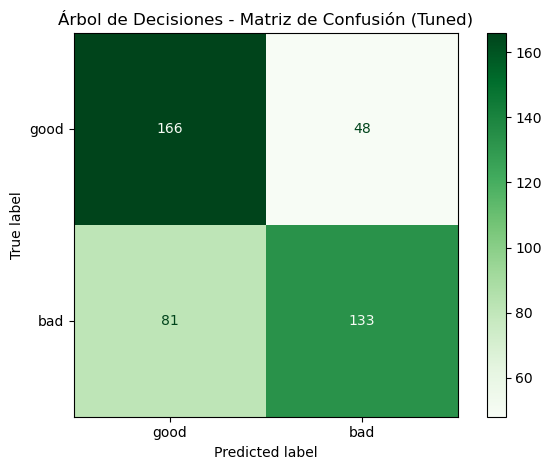

In [167]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - ÁRBOL DE DECISIONES
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

param_grid = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion':        ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train, y_train)

print("=" * 55)
print("   ÁRBOL DE DECISIONES - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {grid_dt.best_params_}")
print(f"Mejor F1 (CV/train): {grid_dt.best_score_:.4f}")

y_pred = grid_dt.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='Greens')
plt.title("Árbol de Decisiones - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()

 MODELO DE RANDOM FOREST

          MODELO DE RANDOM FOREST

Accuracy (70/30):        0.7500

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       214
           1       0.76      0.73      0.75       214

    accuracy                           0.75       428
   macro avg       0.75      0.75      0.75       428
weighted avg       0.75      0.75      0.75       428

Precisión Promedio (CV): 0.7602
Desviación Estándar(CV): 0.0274
Scores por fold:         [0.7273 0.7439 0.7474 0.8035 0.7789]


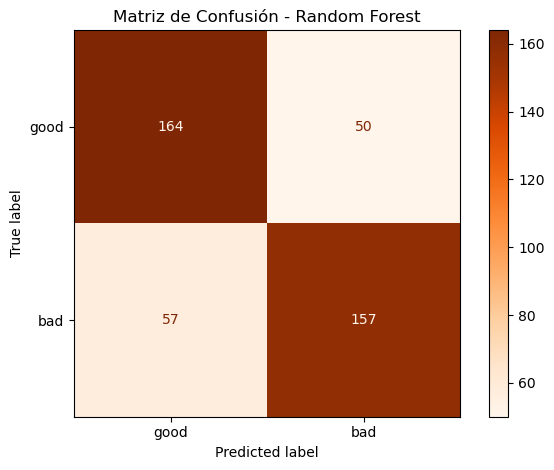

In [168]:
# ============================================================
# MODELO DE RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt
import joblib

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
y_pred = modelo_rf.predict(X_test)

print("=" * 55)
print("          MODELO DE RANDOM FOREST")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_rf, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.show()



AJUSTE DE HIPERPARÁMETROS - RANDOM FOREST

Fitting 5 folds for each of 30 candidates, totalling 150 fits
   RANDOM FOREST - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}
Mejor F1 (CV/train): 0.7351

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.75      0.76      0.76       214
 Clase 1 (bad)       0.76      0.75      0.75       214

      accuracy                           0.75       428
     macro avg       0.75      0.75      0.75       428
  weighted avg       0.75      0.75      0.75       428



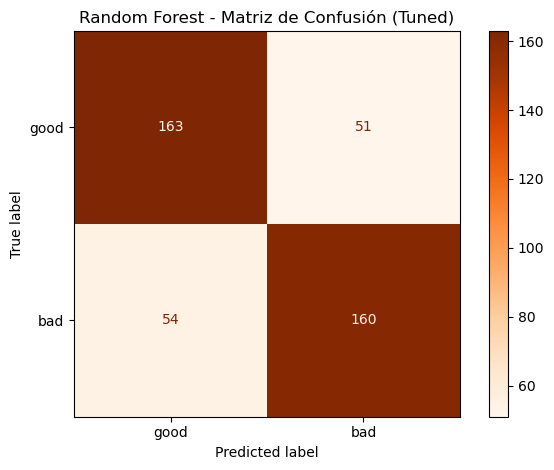

In [169]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# RandomizedSearchCV por el alto costo computacional de RF
param_dist = {
    'n_estimators':     [50, 100, 200, 300],
    'max_depth':        [3, 5, 10, 15, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rand_rf.fit(X_train, y_train)

print("=" * 55)
print("   RANDOM FOREST - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {rand_rf.best_params_}")
print(f"Mejor F1 (CV/train): {rand_rf.best_score_:.4f}")

y_pred = rand_rf.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='Oranges')
plt.title("Random Forest - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()



MODELO DE KNN (K-Nearest Neighbors)

In [170]:
# ============================================================
# MODELO DE KNN (K-Nearest Neighbors)
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
modelo_knn.fit(X_train, y_train)
y_pred = modelo_knn.predict(X_test)

print("=" * 55)
print("       MODELO DE KNN")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_knn, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")


       MODELO DE KNN

Accuracy (70/30):        0.6776

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.64      0.81      0.71       214
           1       0.74      0.55      0.63       214

    accuracy                           0.68       428
   macro avg       0.69      0.68      0.67       428
weighted avg       0.69      0.68      0.67       428

Precisión Promedio (CV): 0.7153
Desviación Estándar(CV): 0.0172
Scores por fold:         [0.7028 0.6912 0.7263 0.7404 0.7158]


AJUSTE DE HIPERPARÁMETROS - KNN

Fitting 5 folds for each of 42 candidates, totalling 210 fits
   KNN - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Mejor F1 (CV/train): 0.7360

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.68      0.86      0.76       214
 Clase 1 (bad)       0.82      0.60      0.69       214

      accuracy                           0.73       428
     macro avg       0.75      0.73      0.73       428
  weighted avg       0.75      0.73      0.73       428



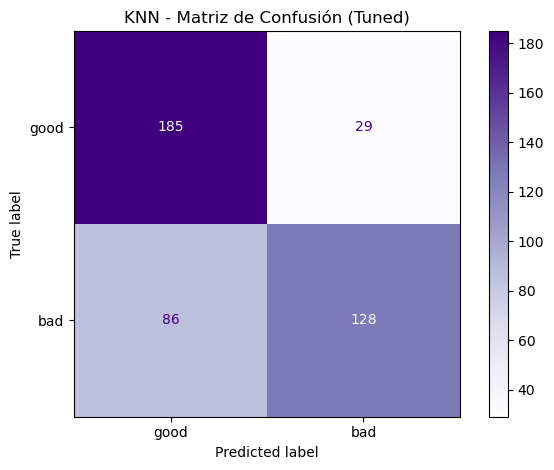

In [171]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - KNN
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'metric':      ['euclidean', 'manhattan', 'minkowski'],
    'weights':     ['uniform', 'distance']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(X_train, y_train)

print("=" * 55)
print("   KNN - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {grid_knn.best_params_}")
print(f"Mejor F1 (CV/train): {grid_knn.best_score_:.4f}")

y_pred = grid_knn.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='Purples')
plt.title("KNN - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()


MODELO SVC (Support Vector Classifier)

       MODELO SVC

Accuracy (70/30):        0.7079

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       214
           1       0.70      0.74      0.72       214

    accuracy                           0.71       428
   macro avg       0.71      0.71      0.71       428
weighted avg       0.71      0.71      0.71       428

Precisión Promedio (CV): 0.7097
Desviación Estándar(CV): 0.0280
Scores por fold:         [0.6888 0.6982 0.7158 0.7614 0.6842]


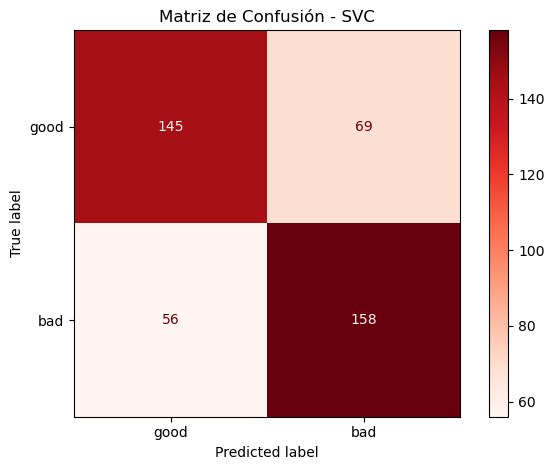

In [172]:
# ============================================================
# MODELO SVC (Support Vector Classifier)
# ============================================================
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
modelo_svc.fit(X_train, y_train)
y_pred = modelo_svc.predict(X_test)

print("=" * 55)
print("       MODELO SVC")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_svc, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='Reds')
plt.title("Matriz de Confusión - SVC")
plt.tight_layout()
plt.show()


AJUSTE DE HIPERPARÁMETROS - SVC

Fitting 5 folds for each of 25 candidates, totalling 125 fits
   SVC - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'kernel': 'rbf', 'gamma': 'scale', 'C': 50}
Mejor F1 (CV/train): 0.7148

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.71      0.80      0.75       214
 Clase 1 (bad)       0.77      0.67      0.71       214

      accuracy                           0.73       428
     macro avg       0.74      0.73      0.73       428
  weighted avg       0.74      0.73      0.73       428



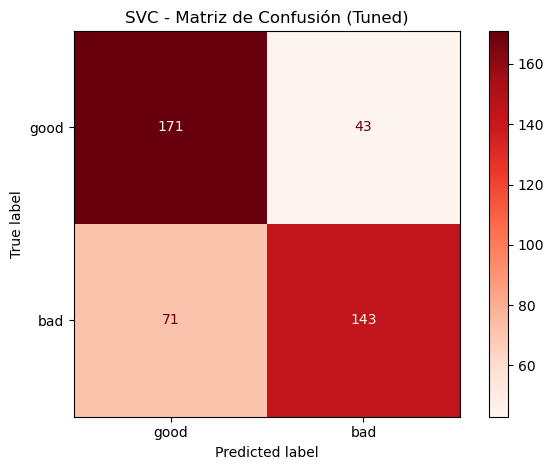

In [173]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - SVC
# ============================================================
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

param_dist = {
    'C':      [0.1, 1, 10, 50, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_svc = RandomizedSearchCV(
    SVC(random_state=42),
    param_dist,
    n_iter=25,
    cv=cv,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rand_svc.fit(X_train, y_train)

print("=" * 55)
print("   SVC - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {rand_svc.best_params_}")
print(f"Mejor F1 (CV/train): {rand_svc.best_score_:.4f}")

y_pred = rand_svc.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='Reds')
plt.title("SVC - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()

 MODELO DE RED NEURONAL (MLPClassifier)

       MODELO DE RED NEURONAL (MLP)

Accuracy (70/30):        0.7780

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       214
           1       0.79      0.76      0.77       214

    accuracy                           0.78       428
   macro avg       0.78      0.78      0.78       428
weighted avg       0.78      0.78      0.78       428

Precisión Promedio (CV): 0.8002
Desviación Estándar(CV): 0.0380
Scores por fold:         [0.7343 0.7825 0.8175 0.8386 0.8281]


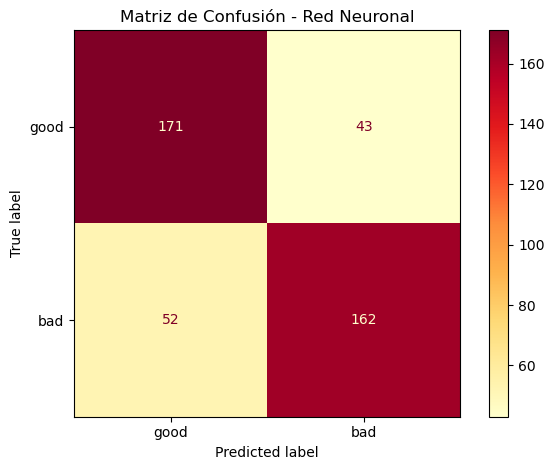

['modelo_red_neuronal1.joblib']

In [174]:
# ============================================================
# MODELO DE RED NEURONAL (MLPClassifier)
# ============================================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt
import joblib

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
modelo_nn.fit(X_train, y_train)
y_pred = modelo_nn.predict(X_test)

print("=" * 55)
print("       MODELO DE RED NEURONAL (MLP)")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_nn, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='YlOrRd')
plt.title("Matriz de Confusión - Red Neuronal")
plt.tight_layout()
plt.show()

joblib.dump(modelo_nn, 'modelo_red_neuronal1.joblib')

 AJUSTE DE HIPERPARÁMETROS - RED NEURONAL (MLP)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
   RED NEURONAL - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'max_iter': 300, 'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.001, 'activation': 'relu'}
Mejor F1 (CV/train): 0.7059

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.74      0.79      0.77       214
 Clase 1 (bad)       0.78      0.73      0.75       214

      accuracy                           0.76       428
     macro avg       0.76      0.76      0.76       428
  weighted avg       0.76      0.76      0.76       428



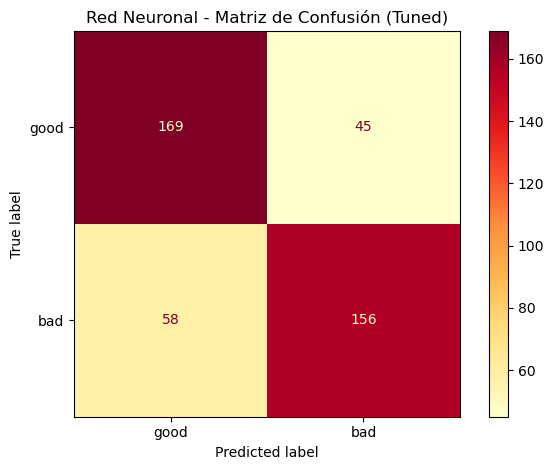

In [175]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - RED NEURONAL (MLP)
# ============================================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.0001],
    'max_iter':           [300, 500]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_nn = RandomizedSearchCV(
    MLPClassifier(solver='adam', random_state=42, early_stopping=True),
    param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rand_nn.fit(X_train, y_train)

print("=" * 55)
print("   RED NEURONAL - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {rand_nn.best_params_}")
print(f"Mejor F1 (CV/train): {rand_nn.best_score_:.4f}")

y_pred = rand_nn.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='YlOrRd')
plt.title("Red Neuronal - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()

 MODELO DE BOOSTING 

       MODELO DE BOOSTING

Accuracy (70/30):        0.6963

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.70      0.68      0.69       214
           1       0.69      0.71      0.70       214

    accuracy                           0.70       428
   macro avg       0.70      0.70      0.70       428
weighted avg       0.70      0.70      0.70       428

Precisión Promedio (CV): 0.7020
Desviación Estándar(CV): 0.0316
Scores por fold:         [0.6608 0.6702 0.7298 0.7404 0.7088]


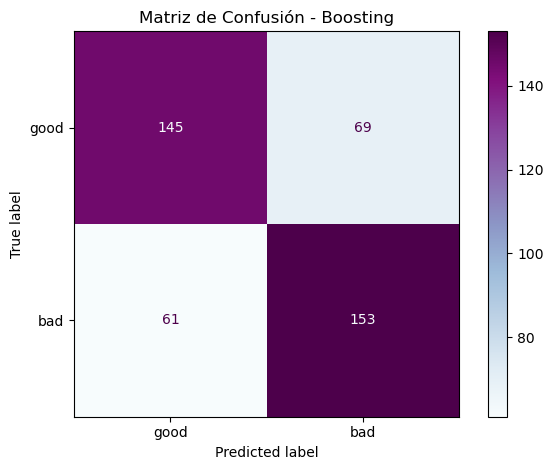

In [176]:
# ============================================================
# MODELO DE BOOSTING (GradientBoostingClassifier)
# ============================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt
import joblib

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_boost = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=3, random_state=42
)
modelo_boost.fit(X_train, y_train)
y_pred = modelo_boost.predict(X_test)

print("=" * 55)
print("       MODELO DE BOOSTING")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_boost, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='BuPu')
plt.title("Matriz de Confusión - Boosting")
plt.tight_layout()
plt.show()


AJUSTE DE HIPERPARÁMETROS - GRADIENT BOOSTING

Fitting 5 folds for each of 30 candidates, totalling 150 fits
   BOOSTING - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.2}
Mejor F1 (CV/train): 0.7268

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.75      0.75      0.75       214
 Clase 1 (bad)       0.75      0.75      0.75       214

      accuracy                           0.75       428
     macro avg       0.75      0.75      0.75       428
  weighted avg       0.75      0.75      0.75       428



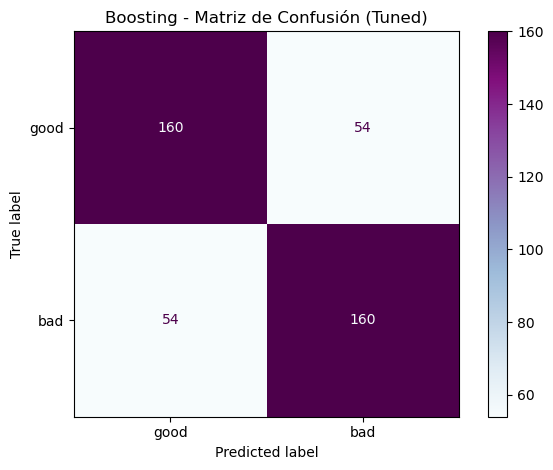

In [177]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - GRADIENT BOOSTING
# ============================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

param_dist = {
    'n_estimators':   [100, 200, 300],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'max_depth':      [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'subsample':      [0.7, 0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_boost = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rand_boost.fit(X_train, y_train)

print("=" * 55)
print("   BOOSTING - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {rand_boost.best_params_}")
print(f"Mejor F1 (CV/train): {rand_boost.best_score_:.4f}")

y_pred = rand_boost.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='BuPu')
plt.title("Boosting - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()

MODELO VOTING CLASSIFIER

       MODELO VOTING CLASSIFIER

Accuracy (70/30):        0.7360

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.73      0.73       214
           1       0.73      0.74      0.74       214

    accuracy                           0.74       428
   macro avg       0.74      0.74      0.74       428
weighted avg       0.74      0.74      0.74       428

Precisión Promedio (CV): 0.7392
Desviación Estándar(CV): 0.0282
Scores por fold:         [0.7098 0.7298 0.7333 0.793  0.7298]


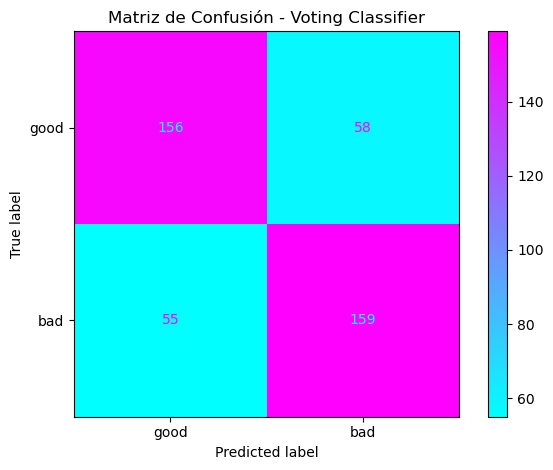

In [178]:
# ============================================================
# MODELO VOTING CLASSIFIER
# ============================================================
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Definir estimadores base
estimadores = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
]

modelo_voting = VotingClassifier(estimators=estimadores, voting='soft')
modelo_voting.fit(X_train, y_train)
y_pred = modelo_voting.predict(X_test)

print("=" * 55)
print("       MODELO VOTING CLASSIFIER")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_voting, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='cool')
plt.title("Matriz de Confusión - Voting Classifier")
plt.tight_layout()
plt.show()


AJUSTE DE HIPERPARÁMETROS - VOTING CLASSIFIER

Fitting 5 folds for each of 10 candidates, totalling 50 fits
   VOTING CLASSIFIER - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'voting': 'hard', 'weights': [1, 2, 1]}
Mejor F1 (CV/train): 0.7058

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.72      0.77      0.74       214
 Clase 1 (bad)       0.75      0.70      0.73       214

      accuracy                           0.74       428
     macro avg       0.74      0.74      0.74       428
  weighted avg       0.74      0.74      0.74       428



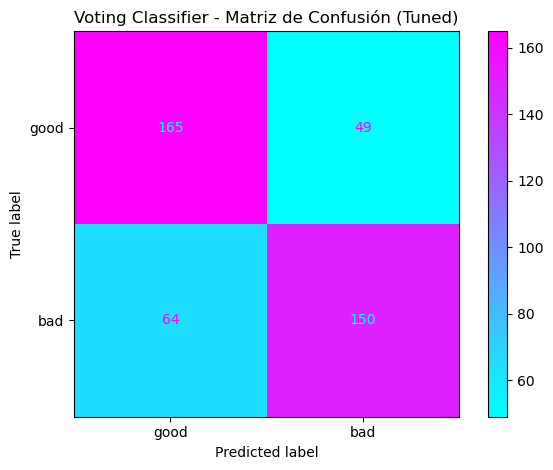

In [179]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - VOTING CLASSIFIER
# ============================================================
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# En Voting se ajustan los pesos de cada estimador base
estimadores = [
    ('lr',    LogisticRegression(max_iter=1000, C=1, random_state=42)),
    ('rf',    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('boost', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

# Se tunea el tipo de voting y los pesos relativos entre modelos
param_grid = {
    'voting':  ['soft', 'hard'],
    'weights': [[1,1,1], [1,2,1], [1,1,2], [2,1,1], [1,2,2]]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_voting = GridSearchCV(
    VotingClassifier(estimators=estimadores),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_voting.fit(X_train, y_train)

print("=" * 55)
print("   VOTING CLASSIFIER - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {grid_voting.best_params_}")
print(f"Mejor F1 (CV/train): {grid_voting.best_score_:.4f}")

y_pred = grid_voting.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='cool')
plt.title("Voting Classifier - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()


 MODELO DE BAGGING CLASSIFIER

       MODELO DE BAGGING CLASSIFIER

Accuracy (70/30):        0.6963

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69       214
           1       0.69      0.70      0.70       214

    accuracy                           0.70       428
   macro avg       0.70      0.70      0.70       428
weighted avg       0.70      0.70      0.70       428

Precisión Promedio (CV): 0.7118
Desviación Estándar(CV): 0.0337
Scores por fold:         [0.6608 0.7298 0.7333 0.7509 0.6842]


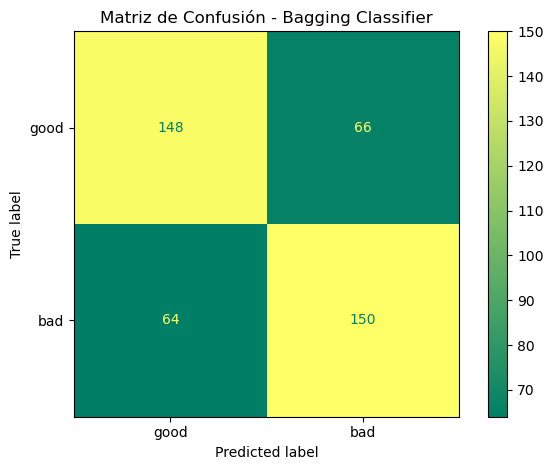

In [180]:
# ============================================================
# MODELO DE BAGGING CLASSIFIER
# ============================================================
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
modelo_bagging.fit(X_train, y_train)
y_pred = modelo_bagging.predict(X_test)

print("=" * 55)
print("       MODELO DE BAGGING CLASSIFIER")
print("=" * 55)
print(f"\nAccuracy (70/30):        {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(modelo_bagging, X, y, cv=5, scoring='accuracy')
print(f"Precisión Promedio (CV): {cv_scores.mean():.4f}")
print(f"Desviación Estándar(CV): {cv_scores.std():.4f}")
print(f"Scores por fold:         {np.round(cv_scores, 4)}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'bad'])
disp.plot(cmap='summer')
plt.title("Matriz de Confusión - Bagging Classifier")
plt.tight_layout()
plt.show()

 AJUSTE DE HIPERPARÁMETROS - BAGGING CLASSIFIER

Fitting 5 folds for each of 108 candidates, totalling 540 fits
   BAGGING - MEJORES HIPERPARÁMETROS
Mejores parámetros: {'estimator__max_depth': None, 'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 200}
Mejor F1 (CV/train): 0.7349

Reporte final sobre Test (30%):
                precision    recall  f1-score   support

Clase 0 (good)       0.76      0.77      0.76       214
 Clase 1 (bad)       0.77      0.75      0.76       214

      accuracy                           0.76       428
     macro avg       0.76      0.76      0.76       428
  weighted avg       0.76      0.76      0.76       428



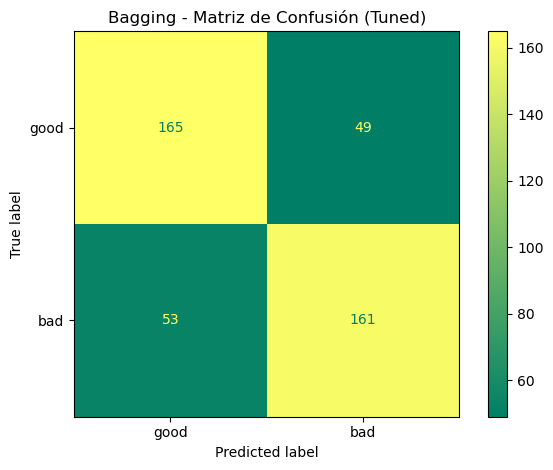

In [126]:
# ============================================================
# AJUSTE DE HIPERPARÁMETROS - BAGGING CLASSIFIER
# ============================================================
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df_balanceado = joblib.load('df_Credito_balanceado.joblib')
X = df_balanceado.drop(columns=['Risk_ENCODED'])
y = df_balanceado['Risk_ENCODED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_samples':   [0.6, 0.8, 1.0],
    'max_features':  [0.6, 0.8, 1.0],
    'estimator__max_depth': [3, 5, 10, None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_bagging = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_bagging.fit(X_train, y_train)

print("=" * 55)
print("   BAGGING - MEJORES HIPERPARÁMETROS")
print("=" * 55)
print(f"Mejores parámetros: {grid_bagging.best_params_}")
print(f"Mejor F1 (CV/train): {grid_bagging.best_score_:.4f}")

y_pred = grid_bagging.best_estimator_.predict(X_test)
print("\nReporte final sobre Test (30%):")
print(classification_report(y_test, y_pred, target_names=['Clase 0 (good)', 'Clase 1 (bad)']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['good','bad']).plot(cmap='summer')
plt.title("Bagging - Matriz de Confusión (Tuned)")
plt.tight_layout(); plt.show()


In [ ]:
df.to_csv('dataset_final_procesado.csv', index=False)